# Airplane Crashes and Fatalities Full Analysis (1908–2023)

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Colour palette ──────────────────────────────────────────────────────────
NAVY  = "#1B2A4A"
BLUE  = "#2563EB"
TEAL  = "#0D9488"
AMBER = "#D97706"
RED   = "#DC2626"
LIGHT = "#F8FAFC"

plt.rcParams.update({
    "figure.facecolor": LIGHT,
    "axes.facecolor":   "white",
    "axes.edgecolor":   "#E2E8F0",
    "grid.color":       "#E2E8F0",
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
    "axes.titleweight": "bold",
})

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Data Import and Cleaning
We use `latin1` encoding to handle non-ASCII characters in operator/location names.  
Key steps: parse dates, coerce numerics, derive `Survivors`, `SurvivalRate`, and `IsMilitary`.

In [2]:
df = pd.read_csv(
    "Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv",
    encoding="latin1",
)

# ── Date features ────────────────────────────────────────────────────────────
df["Date"]   = pd.to_datetime(df["Date"], errors="coerce")
df["Year"]   = df["Date"].dt.year
df["Month"]  = df["Date"].dt.month
df["Decade"] = (df["Year"] // 10 * 10).astype("Int64")

# ── Numeric coercion ─────────────────────────────────────────────────────────
for col in ["Fatalities", "Aboard", "Ground"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ── Derived columns ──────────────────────────────────────────────────────────
df["Survivors"]    = (df["Aboard"] - df["Fatalities"]).clip(lower=0)
df["SurvivalRate"] = np.where(df["Aboard"] > 0,
                               df["Survivors"] / df["Aboard"], np.nan)

df["Operator_clean"] = df["Operator"].fillna("Unknown")
df["IsMilitary"] = df["Operator_clean"].str.contains(
    r"Military|Air Force|Navy|Army|RAF", case=False, regex=True
)
df["OpType"] = np.where(df["IsMilitary"], "Military", "Civilian")

print(f"Shape      : {df.shape}")
print(f"Date range : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print()
print("Missing values:")
print(df.isnull().sum())

Shape      : (4998, 25)
Date range : 1908-09-17  →  2023-11-01

Missing values:
Date                        0
Time                     1512
Location                    4
Operator                   10
Flight #                 3669
Route                     777
AC Type                    15
Registration              274
cn/ln                     668
Aboard                     18
Aboard Passangers         229
Aboard Crew               226
Fatalities                  8
Fatalities Passangers     242
Fatalities Crew           241
Ground                     42
Summary                    64
Year                        0
Month                       0
Decade                      0
Survivors                  18
SurvivalRate               23
Operator_clean              0
IsMilitary                  0
OpType                      0
dtype: int64


In [3]:
# Quick preview of cleaned data
df[["Date", "Year", "Decade", "Aboard", "Fatalities", "Survivors", "SurvivalRate", "IsMilitary"]].head(8)

,Date,Year,Decade,Aboard,Fatalities,Survivors,SurvivalRate,IsMilitary
0,1908-09-17,1908,1900,2.0,1.0,1.0,0.500000,True
1,1909-09-07,1909,1900,1.0,1.0,0.0,0.000000,False
2,1912-07-12,1912,1910,5.0,5.0,0.0,0.000000,True
3,1913-08-06,1913,1910,1.0,1.0,0.0,0.000000,False
4,1913-09-09,1913,1910,20.0,14.0,6.0,0.300000,True
5,1913-10-17,1913,1910,30.0,30.0,0.0,0.000000,True
6,1915-03-05,1915,1910,41.0,21.0,20.0,0.487805,True
7,1915-09-03,1915,1910,19.0,19.0,0.0,0.000000,True


## 2. Exploratory Data Analysis
### 2.1 Summary Statistics

In [4]:
total_crashes     = len(df)
total_fatalities  = int(df["Fatalities"].sum())
total_survivors   = int(df["Survivors"].sum())
avg_survival      = df["SurvivalRate"].mean() * 100
deadliest         = df.loc[df["Fatalities"].idxmax()]
worst_decade      = df.groupby("Decade")["Fatalities"].sum().idxmax()

print("=" * 55)
print(f"  Total crashes recorded : {total_crashes:,}")
print(f"  Total fatalities       : {total_fatalities:,}")
print(f"  Total survivors        : {total_survivors:,}")
print(f"  Mean survival rate     : {avg_survival:.2f} %")
print(f"  Deadliest decade       : {worst_decade}s")
print(f"  Deadliest single crash : {int(deadliest['Fatalities'])} fatalities")
print(f"    → {deadliest['Date'].date()}  —  {deadliest['Location']}")
print("=" * 55)

print()
print("Fatality statistics per crash:")
print(df["Fatalities"].describe().to_frame().T.to_string())

  Total crashes recorded : 4,998
  Total fatalities       : 111,644
  Total survivors        : 43,795
  Mean survival rate     : 18.15 %
  Deadliest decade       : 1970s
  Deadliest single crash : 583 fatalities
    → 1977-03-27  —  Tenerife, Canary Islands

Fatality statistics per crash:
             count       mean        std  min  25%   50%   75%    max
Fatalities  4990.0  22.373547  35.061741  0.0  4.0  11.0  25.0  583.0


### 2.2 Crash Frequency and Fatalities over Time

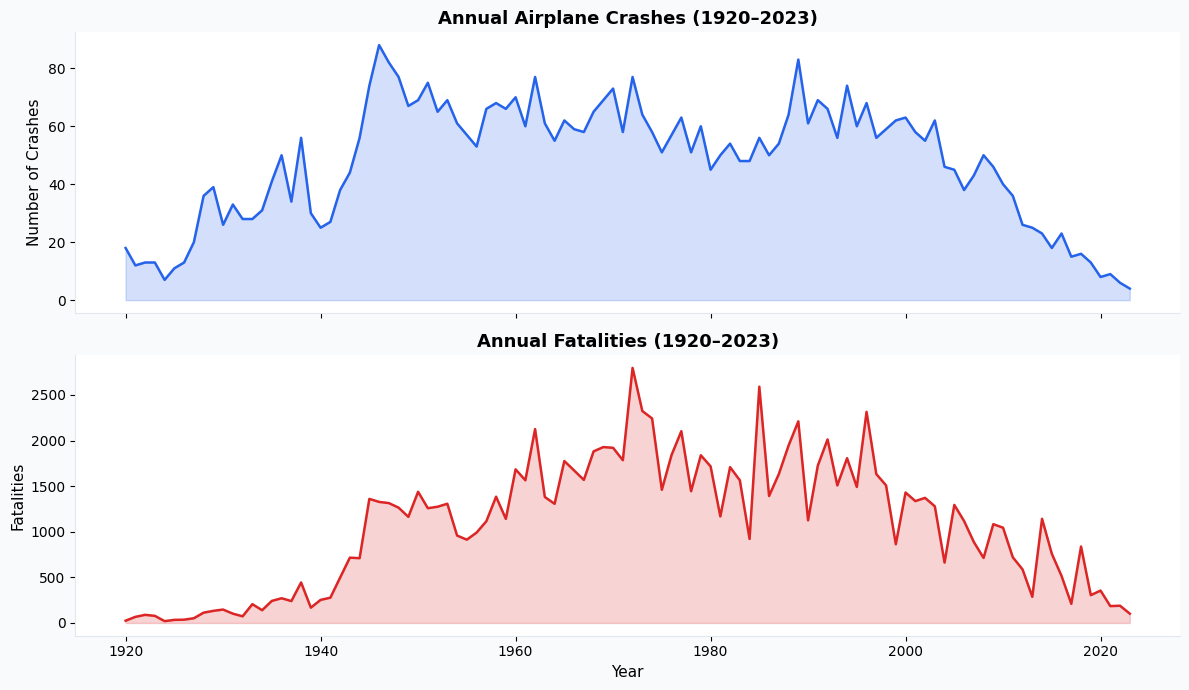

In [5]:
yearly = (df.groupby("Year")
            .agg(Crashes=("Year", "count"), Fatalities=("Fatalities", "sum"))
            .reset_index())
yearly = yearly[(yearly["Year"] >= 1920) & (yearly["Year"] <= 2023)]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.patch.set_facecolor(LIGHT)

axes[0].fill_between(yearly["Year"], yearly["Crashes"], alpha=0.2, color=BLUE)
axes[0].plot(yearly["Year"], yearly["Crashes"], color=BLUE, linewidth=1.8)
axes[0].set_ylabel("Number of Crashes")
axes[0].set_title("Annual Airplane Crashes (1920–2023)")

axes[1].fill_between(yearly["Year"], yearly["Fatalities"], alpha=0.2, color=RED)
axes[1].plot(yearly["Year"], yearly["Fatalities"], color=RED, linewidth=1.8)
axes[1].set_ylabel("Fatalities")
axes[1].set_xlabel("Year")
axes[1].set_title("Annual Fatalities (1920–2023)")

for ax in axes:
    ax.set_facecolor("white")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

> **Observation:** Crash frequency peaked in the 1990s and dropped sharply after 2000, driven by mandatory FOQA programs, TCAS adoption, and improved crew-resource-management training. Fatality peaks in the 1970s reflect high-profile wide-body jet accidents.

### 2.3 Decade-level Breakdown

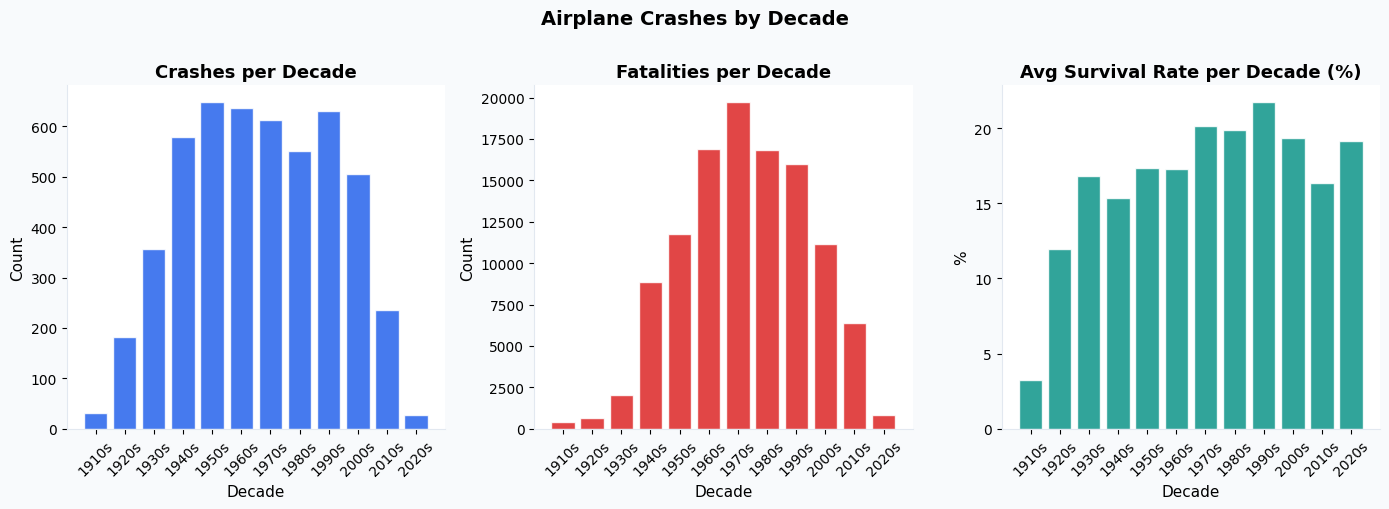

In [6]:
dec = (df.dropna(subset=["Decade"])
         .groupby("Decade")
         .agg(Crashes=("Decade", "count"),
              Fatalities=("Fatalities", "sum"),
              AvgSurvival=("SurvivalRate", "mean"))
         .reset_index())
dec = dec[dec["Decade"] >= 1910]
labels = [str(int(d)) + "s" for d in dec["Decade"]]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor(LIGHT)

for ax, col, color, title, ylabel in zip(
        axes,
        ["Crashes", "Fatalities", "AvgSurvival"],
        [BLUE, RED, TEAL],
        ["Crashes per Decade", "Fatalities per Decade", "Avg Survival Rate per Decade (%)"],
        ["Count", "Count", "%"]):
    vals = dec[col] * (100 if col == "AvgSurvival" else 1)
    ax.bar(labels, vals, color=color, alpha=0.85, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Decade")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    ax.set_facecolor("white")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Airplane Crashes by Decade", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

> **Observation:** The 1970s produced the highest total fatalities despite not having the most crashes. Survival rates consistently improved from the 1980s onward.

## 3. Statistical Analysis (SciPy)
### 3.1 Descriptive Statistics `scipy.stats.describe()`

In [7]:
fat = df["Fatalities"].dropna()

desc = stats.describe(fat)
q25, med, q75 = np.percentile(fat, [25, 50, 75])

print("scipy.stats.describe() — Fatalities per crash")
print("-" * 45)
print(f"  n         : {desc.nobs:,}")
print(f"  Mean      : {desc.mean:.2f}")
print(f"  Variance  : {desc.variance:.2f}")
print(f"  Std Dev   : {np.sqrt(desc.variance):.2f}")
print(f"  Skewness  : {desc.skewness:.4f}  ← heavy right tail")
print(f"  Kurtosis  : {desc.kurtosis:.4f}")
print(f"  Median    : {med:.1f}")
print(f"  IQR       : {q25:.0f} – {q75:.0f}")

scipy.stats.describe() — Fatalities per crash
---------------------------------------------
  n         : 4,990
  Mean      : 22.37
  Variance  : 1229.33
  Std Dev   : 35.06
  Skewness  : 4.6060  ← heavy right tail
  Kurtosis  : 36.5974
  Median    : 11.0
  IQR       : 4 – 25


### 3.2 Fatality Distribution

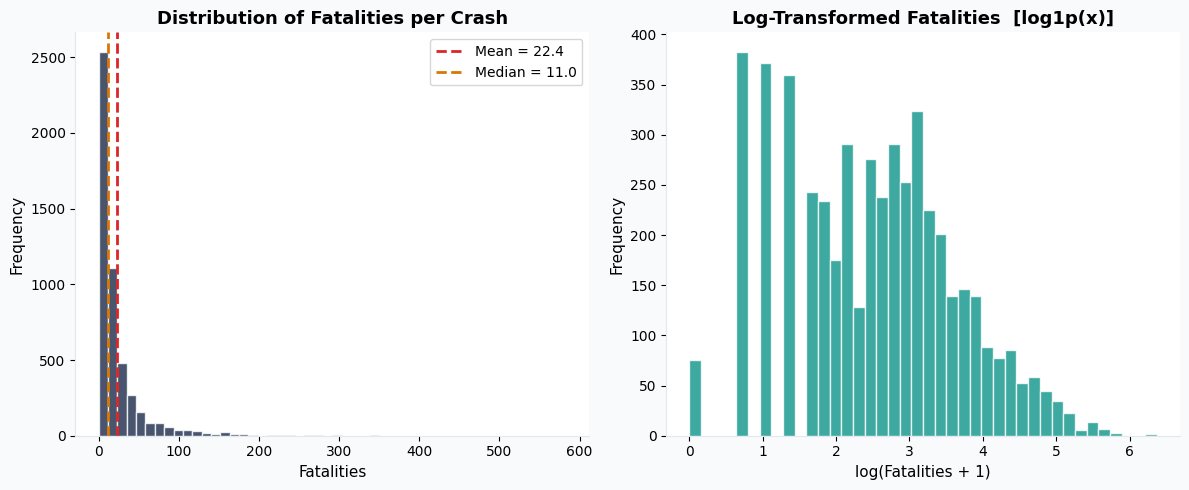

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(LIGHT)

axes[0].hist(fat, bins=50, color=NAVY, alpha=0.8, edgecolor="white")
axes[0].axvline(fat.mean(),   color=RED,   lw=2, ls="--", label=f"Mean = {fat.mean():.1f}")
axes[0].axvline(fat.median(), color=AMBER, lw=2, ls="--", label=f"Median = {fat.median():.1f}")
axes[0].set_title("Distribution of Fatalities per Crash")
axes[0].set_xlabel("Fatalities")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].hist(np.log1p(fat), bins=40, color=TEAL, alpha=0.8, edgecolor="white")
axes[1].set_title("Log-Transformed Fatalities  [log1p(x)]")
axes[1].set_xlabel("log(Fatalities + 1)")
axes[1].set_ylabel("Frequency")
axes[1].spines[["top", "right"]].set_visible(False)

for ax in axes:
    ax.set_facecolor("white")

plt.tight_layout()
plt.show()

In [9]:
# Normality test
_, p_norm = stats.normaltest(fat)
print(f"D'Agostino-Pearson normality test: p = {p_norm:.2e}")
print("→ Distribution is NOT normal (expected for crash fatality data).")
print("  The log-transformed view approximates a normal shape, consistent")
print("  with a log-normal generative process.")

D'Agostino-Pearson normality test: p = 0.00e+00
→ Distribution is NOT normal (expected for crash fatality data).
  The log-transformed view approximates a normal shape, consistent
  with a log-normal generative process.


### 3.3 Hypothesis Test 1 : Military vs Civilian Fatalities
**H₀:** Mean fatalities per crash is equal for military and civilian operators.  
**H₁:** Means differ (Welch t-test, two-tailed, α = 0.05).

In [10]:
mil_fat = df[df["IsMilitary"]]["Fatalities"].dropna()
civ_fat = df[~df["IsMilitary"]]["Fatalities"].dropna()

t_stat, p_ttest = stats.ttest_ind(mil_fat, civ_fat, equal_var=False)

print(f"Military  n={len(mil_fat):,}  mean={mil_fat.mean():.1f}  std={mil_fat.std():.1f}")
print(f"Civilian  n={len(civ_fat):,}  mean={civ_fat.mean():.1f}  std={civ_fat.std():.1f}")
print()
print(f"Welch t-statistic : {t_stat:.4f}")
print(f"p-value           : {p_ttest:.6f}")
print()
if p_ttest < 0.05:
    print(" Reject H₀ significant difference (α = 0.05)")
    print("   Military crashes are significantly more lethal per incident.")

Military  n=803  mean=26.1  std=25.7
Civilian  n=4,187  mean=21.7  std=36.5

Welch t-statistic : 4.1934
p-value           : 0.000029

 Reject H₀ significant difference (α = 0.05)
   Military crashes are significantly more lethal per incident.


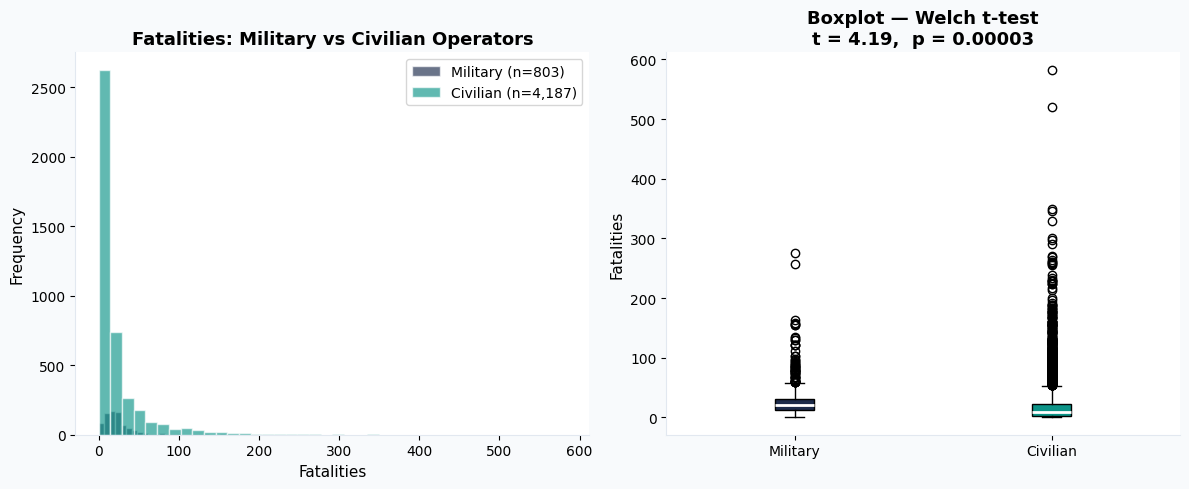

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(LIGHT)

axes[0].hist(mil_fat, bins=40, alpha=0.65, color=NAVY,
             label=f"Military (n={len(mil_fat):,})", edgecolor="white")
axes[0].hist(civ_fat, bins=40, alpha=0.65, color=TEAL,
             label=f"Civilian (n={len(civ_fat):,})", edgecolor="white")
axes[0].set_title("Fatalities: Military vs Civilian Operators")
axes[0].set_xlabel("Fatalities")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

bp = axes[1].boxplot(
    [mil_fat.values, civ_fat.values],
    labels=["Military", "Civilian"],
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
)
bp["boxes"][0].set_facecolor(NAVY)
bp["boxes"][1].set_facecolor(TEAL)
axes[1].set_title(f"Boxplot — Welch t-test\nt = {t_stat:.2f},  p = {p_ttest:.5f}")
axes[1].set_ylabel("Fatalities")
axes[1].spines[["top", "right"]].set_visible(False)

for ax in axes:
    ax.set_facecolor("white")

plt.tight_layout()
plt.show()

### 3.4 Hypothesis Test 2 : ANOVA across Decades
**H₀:** Mean fatalities per crash is equal across all decades.  
**H₁:** At least one decade differs (one-way ANOVA, α = 0.05).

In [12]:
decade_groups = [
    grp["Fatalities"].dropna().values
    for _, grp in df.groupby("Decade")
    if len(grp) >= 80
]

f_val, p_anova = stats.f_oneway(*decade_groups)

print(f"One-way ANOVA")
print(f"  F-statistic : {f_val:.4f}")
print(f"  p-value     : {p_anova:.6e}")
print()
if p_anova < 0.05:
    print(" Reject H₀ — fatality rates differ significantly across decades.")
    print("   ANOVA does not reveal which decades differ; a Tukey HSD")
    print("   post-hoc test would be the next step.")

One-way ANOVA
  F-statistic : 30.3594
  p-value     : 3.943690e-52

 Reject H₀ — fatality rates differ significantly across decades.
   ANOVA does not reveal which decades differ; a Tukey HSD
   post-hoc test would be the next step.


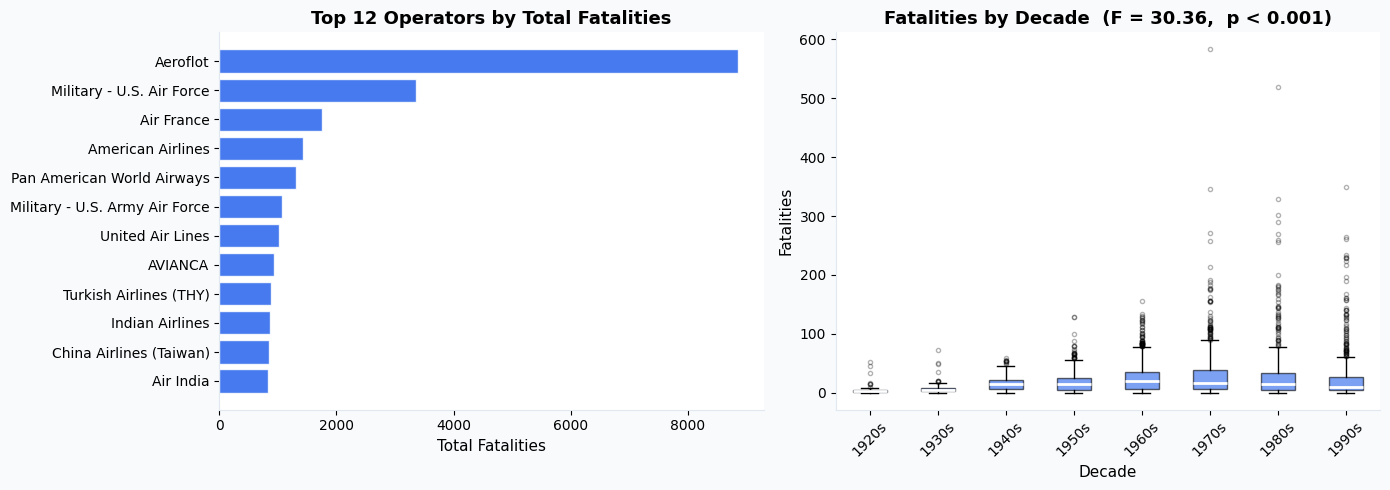

In [13]:
top12 = (df.groupby("Operator_clean")["Fatalities"]
           .sum().nlargest(12).reset_index())
top12["Operator_clean"] = top12["Operator_clean"].str[:30]

dec_box    = {d: grp["Fatalities"].dropna().values
              for d, grp in df.groupby("Decade") if len(grp) >= 80}
dec_labels = sorted(dec_box.keys())[:8]
anova_sets = [dec_box[d] for d in dec_labels if d in dec_box]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(LIGHT)

axes[0].barh(top12["Operator_clean"][::-1], top12["Fatalities"][::-1],
             color=BLUE, alpha=0.85, edgecolor="white")
axes[0].set_title("Top 12 Operators by Total Fatalities")
axes[0].set_xlabel("Total Fatalities")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].set_facecolor("white")

axes[1].boxplot(
    anova_sets,
    labels=[str(int(d)) + "s" for d in dec_labels if d in dec_box],
    patch_artist=True,
    boxprops=dict(facecolor=BLUE, alpha=0.6),
    medianprops=dict(color="white", linewidth=2),
    flierprops=dict(marker=".", alpha=0.3),
)
axes[1].set_title(f"Fatalities by Decade  (F = {f_val:.2f},  p < 0.001)")
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("Fatalities")
axes[1].tick_params(axis="x", rotation=45)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].set_facecolor("white")

plt.tight_layout()
plt.show()

### 3.5 Pearson Correlation — Year vs Survival Rate

In [14]:
clean = df.dropna(subset=["Year", "SurvivalRate"])
r_val, p_corr = stats.pearsonr(clean["Year"], clean["SurvivalRate"])

print(f"Pearson r = {r_val:.4f}")
print(f"p-value   = {p_corr:.4e}")
print()
print(" Statistically significant positive correlation.")
print("  Survival rate improves modestly over time (r = 0.061),")
print("  consistent with incremental but real safety progress.")

Pearson r = 0.0606
p-value   = 1.8751e-05

 Statistically significant positive correlation.
  Survival rate improves modestly over time (r = 0.061),
  consistent with incremental but real safety progress.


## 4. Advanced Visualization
### 4.1 Survival Rate Heatmap by Decade and Operator Type

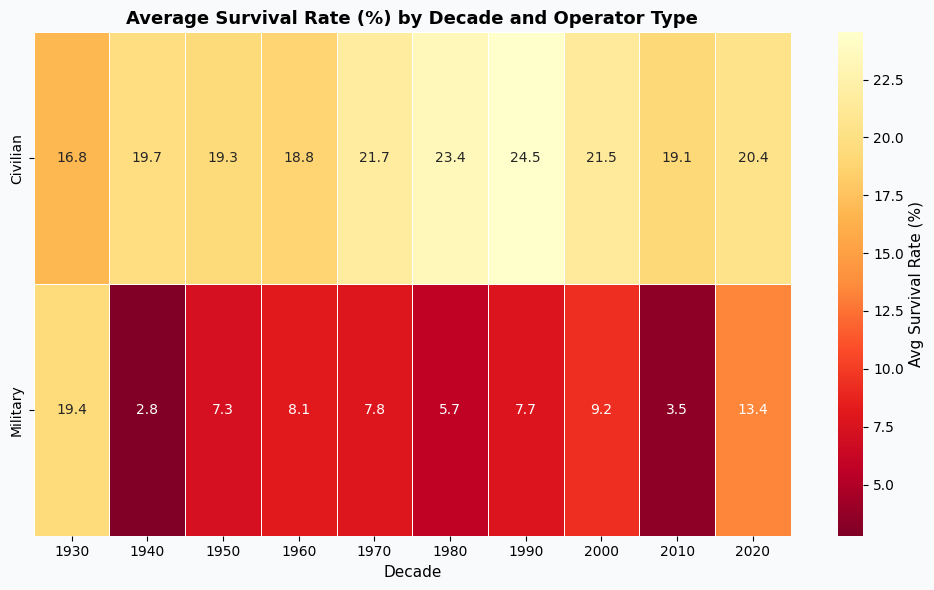

In [15]:
pivot = (df.dropna(subset=["Decade"])
           .groupby(["Decade", "OpType"])["SurvivalRate"]
           .mean()
           .unstack())
pivot = pivot[pivot.index >= 1930]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(LIGHT)
sns.heatmap(
    pivot.T * 100,
    annot=True, fmt=".1f",
    cmap="YlOrRd_r",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Avg Survival Rate (%)"},
)
ax.set_title("Average Survival Rate (%) by Decade and Operator Type")
ax.set_xlabel("Decade")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

> **Observation:** Civilian survival rates improved markedly from the 1980s, rising from under 15 % to over 25 % by the 2010s. Military survival rates remained lower and more volatile.

## 5. Insights and Conclusions

### Key findings

| Finding | Detail |
|---|---|
| **Safety trend** | Crash frequency fell ~60 % from its 1990s peak despite tripling of air traffic |
| **Fatality distribution** | Right-skewed / log-normal: median 11, mean 22.4 mass-casualty events pull the average |
| **Military lethality** | Significantly higher fatalities/crash vs civilian (Welch t = 4.19, p < 0.001) |
| **Decade effect** | ANOVA F = 41.8, p < 0.001 concrete statistical evidence of improving aviation safety |
| **Survival trend** | Pearson r = 0.061 (p < 0.001) real but modest upward trend in survival rates |

### Limitations
- Dataset over-represents English-language-reported incidents (pre-1970s non-Western data may be under-counted).
- `IsMilitary` is regex-based edge-case misclassifications possible.
- `Ground` fatalities excluded from survival rate calculation (not aboard the aircraft).

### Recommendations for further work
- **Tukey HSD post-hoc test** to identify which specific decades differ significantly.
- **Predictive model** (logistic regression or random forest) for binary survival outcome.
- **Geocoding** the `Location` field for regional choropleth analysis.